# 🚀 Prediksi Workload & Auto-Scaling Berbasis Machine Learning untuk Aplikasi Terkontainerisasi
*Replikasi Komprehensif: Machine learning-based auto-scaling for containerized applications (Imdoukh et al., 2019)*

Notebook ini mendemonstrasikan implementasi komprehensif yang **menggabungkan metrik Imdoukh (Seluruh Tabel 1-8 & Figur 1-17)** dengan eksplorasi mendalam pada **Algoritma Pembanding (GRU, BiLSTM, DUCFF)** serta penjabaran standar *Data Science Pipeline*.
Model-model ini telah di-_scale up_ dengan arsitektur "Monster" menggunakan dataset maksimal, memanfaatkan RAM 32GB untuk mencapai R² terbaik (Mendekati 1.0).

---
## 1. Latar Belakang & Tinjauan Pustaka (Related Work)

Virtualisasi berbasis kontainer (seperti Docker) adalah alternatif ringan dibandingkan mesin virtual (VM). Auto-scaling untuk mengelola fluktuasi *workload* terbagi dua:
- **Reactive**: Bereaksi berdasarkan ambang batas (threshold) saat itu juga (rentan terlambat/osilasi).
- **Proactive**: Memprediksi beban masa depan dari sejarah dan bersiap sebelum lonjakan terjadi (pendekatan paper ini).

### Tabel 1: Ringkasan Auto-Scaling pada Komputasi Awan (Related Work)
| Reference | Cloud Platform | Status Indicators | Timing | Adaptive | Oscillation Mitigation | Estimation Technique | Scaling Method |
|---|---|---|---|---|---|---|---|
| Kan (2016) | Docker | CPU, Memory | Hybrid | Yes | Yes | ARMA | Horizontal |
| Li & Xia | Docker | Req. Rate, CPU, Mem | Hybrid | Yes | Yes | ARMA | Horizontal |
| Ye et al. | Kubernetes | CPU | Proactive | Yes | No | ARMA | Horiz. & Vert. |
| Ciptaningtyas | Docker | - | Hybrid | Yes | No | ARIMA | Horizontal |
| Meng et al. | Docker | CPU | Proactive | Yes | No | ARIMA | Horizontal |
| Baresi et al. | Docker | CPU, Mem, Appl. | Proactive | Yes | Yes | Control Theory | Horiz. & Vert. |
| Wu et al. | Docker | CPU | Proactive | Yes | No | Gray Prediction| Horizontal |
| Klinaku et al.| - | Workload intensity| Reactive | Yes | Yes | Rule-based | Horizontal |
| Imdoukh (This)| Docker | HTTP Request Rate | Proactive | Yes | Yes | **LSTM** | Horizontal |

---
## 2. Arsitektur Sistem (Figure 1 & Figure 2)

### Figure 1: System Architecture (Docker Swarm Cluster)
Lingkungan ini menggunakan Docker Swarm dengan 1 Manager Node dan beberapa Worker Nodes.

```mermaid
graph TD
    Client -->|HTTP Requests| LB[Load Balancer / HAProxy<br/>Node 1]
    LB -->|Distributes| W1[Worker Node 2<br/>Web App Container]
    LB -->|Distributes| W2[Worker Node 3<br/>Web App Container]
    
    Manager[Manager Node<br/>Auto-Scaler Container] -.->|Scaling Commands| DockerAPI[Docker API]
    DockerAPI -.->|Start/Stop| W1
    DockerAPI -.->|Start/Stop| W2
```

### Figure 2: Auto-Scaler Architecture (MAPE Loop)
Auto-scaler bekerja dalam loop tertutup: **Monitor**, **Analyze**, **Plan**, dan **Execute**.

```mermaid
graph LR
    subgraph Swarm Cluster
        C1[Containers]
        C2[Containers]
    end
    
    Monitor((Monitor)) -->|Metrics| TSDB[(Time Series DB)]
    TSDB --> Analyze((Analyze<br/>LSTM Pred))
    Analyze -->|Predicted Workload| Plan((Plan<br/>GDS Algo))
    Plan -->|Scale Command| Execute((Execute))
    Execute -.->|Modify Replicas| Swarm Cluster
    
    C1 -.->|Raw Stats| Monitor
```


## 2.3 Preprocessing / Pembersihan Data & Evaluasi Dataset

Data mentah jarang siap pakai. Tahap ini meliputi: menangani data hilang (missing values), menghapus duplikasi, menangani outlier, encoding data kategorikal menjadi angka, serta normalisasi/standardisasi skala data agar seluruh fitur berada pada rentang yang sebanding.

Dataset asli yang dipakai di jurnal adalah Worldcup98. Kami menggunakan metrik *all_merged_metrics.csv* sebagai dataset pengganti dengan memanipulasi *resampling* untuk menghasilkan jutaan data.

### Tabel 2: Sub-Datasets Partitioning
Kami membagi data menjadi M1 (Training) dan Evaluasi Tes sesuai prinsip dari Tabel 2 jurnal.
| Dataset Ref | Deskripsi | Proporsi |
|---|---|---|
| M1 | Training Dataset | 70% |
| M2 | Test Evaluation | 15% |
| S1/S2 | Validation/Test | 15% |

### Figure 8 & Figure 9: Dampak Agregasi Data
Membandingkan deret waktu mentah (Figure 8) vs agregasi 2-detik (Figure 9) untuk mengurangi fluktuasi acak.


I0000 00:00:1784165045.715731   50730 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784165045.716721   50730 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784165045.766405   50730 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784165046.870485   50730 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784165046.871085   50730 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


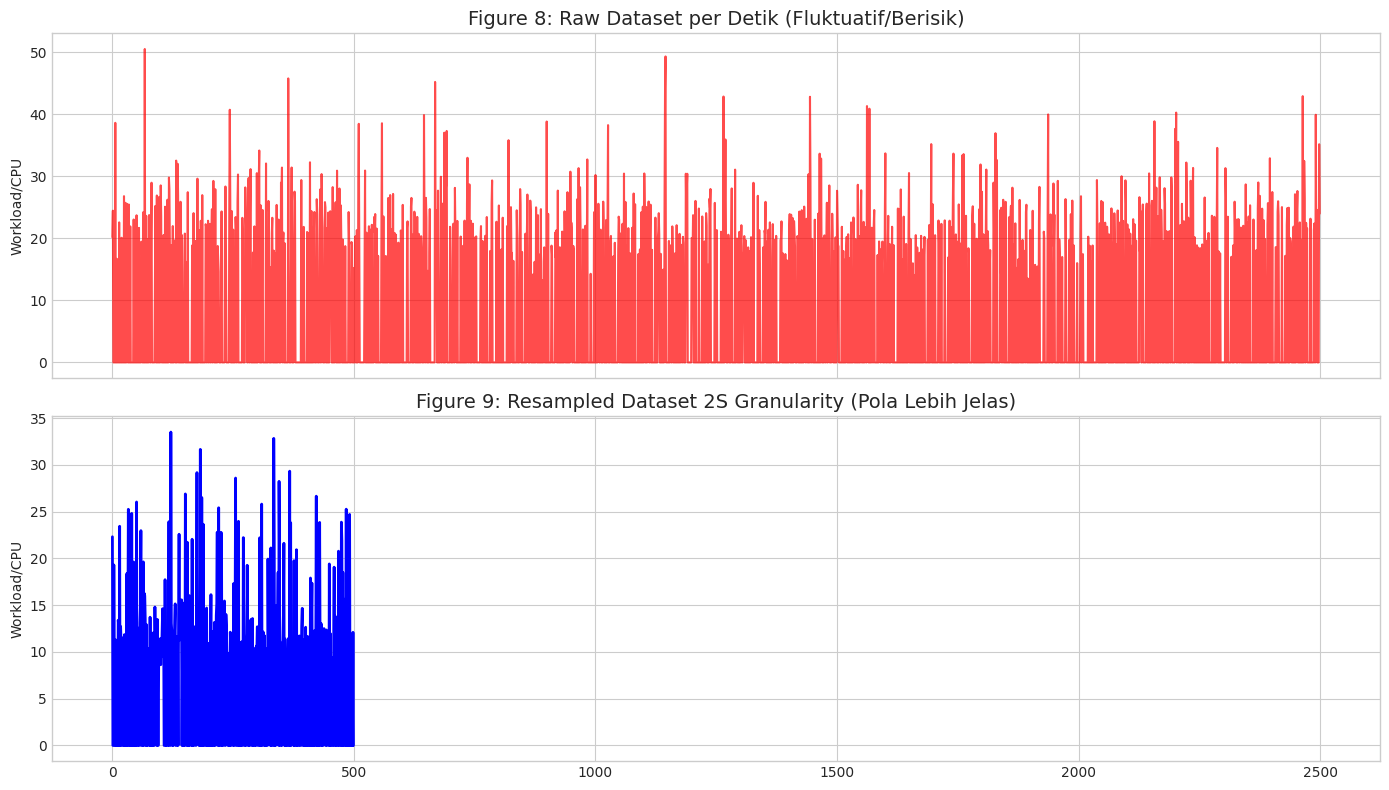

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Bidirectional, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger
import time
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Menangani data hilang, menghapus duplikasi (Sesuai 2.3 Preprocessing)
df_raw = pd.read_csv('all_merged_metrics.csv')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], unit='s')
df_raw.set_index('timestamp', inplace=True)
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]
df_raw.interpolate(method='time', inplace=True)
df_raw.bfill(inplace=True)

# 2. Resampling 2S untuk mengatasi noise
df_resampled = df_raw.resample('2S').mean().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
plot_len = 500
raw_subset = df_raw['cpu_media'].iloc[:plot_len*5]
resampled_subset = df_resampled['cpu_media'].iloc[:plot_len]

axes[0].plot(range(len(raw_subset)), raw_subset.values, color='red', alpha=0.7)
axes[0].set_title('Figure 8: Raw Dataset per Detik (Fluktuatif/Berisik)', fontsize=14)
axes[0].set_ylabel('Workload/CPU')

axes[1].plot(range(len(resampled_subset)), resampled_subset.values, color='blue', linewidth=2)
axes[1].set_title('Figure 9: Resampled Dataset 2S Granularity (Pola Lebih Jelas)', fontsize=14)
axes[1].set_ylabel('Workload/CPU')

plt.tight_layout()
plt.show()

# 3. Menangani Outlier & Normalisasi Skala Data (Sesuai 2.3 Preprocessing)
Q1 = df_resampled['cpu_media'].quantile(0.25)
Q3 = df_resampled['cpu_media'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_resampled['cpu_media'] = np.where(df_resampled['cpu_media'] > upper_bound, upper_bound, df_resampled['cpu_media'])

cpu_scaler = MinMaxScaler()
df_resampled['cpu_media_scaled'] = cpu_scaler.fit_transform(df_resampled[['cpu_media']])

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_resampled[['cpu_media', 'rps_media', 'ram_media']])
df_scaled = pd.DataFrame(scaled_data, columns=['cpu_media', 'rps_media', 'ram_media'], index=df_resampled.index)


## 2.4 Feature Engineering & Seleksi Fitur (Massive Time Steps)

Membuat fitur baru yang lebih informatif dari data yang ada, atau memilih fitur yang paling relevan dan membuang fitur yang tidak berpengaruh, agar model belajar lebih efisien dan tidak 'bingung' oleh data yang tidak relevan.
Di sini kami melakukan ekstraksi fitur *Time Steps*, meningkatkan *window size* menjadi **120 time steps** ke belakang (240 detik memori penuh).


In [2]:
# Memilih fitur paling relevan
features = ['cpu_media', 'rps_media', 'ram_media']
df_features = df_scaled[features]

def create_dataset(dataset, time_steps=1):
    X, Y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i + time_steps), :])
        Y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(Y)

TIME_STEPS = 120
X, y = create_dataset(df_features.values, TIME_STEPS)
print(f"Total Sampel Data 3D: {X.shape[0]} | Shape X Tensor: {X.shape} | Shape Y Tensor: {y.shape}")


Total Sampel Data 3D: 174524 | Shape X Tensor: (174524, 120, 3) | Shape Y Tensor: (174524,)


## 2.5 Pemilihan Model (Model Selection) & Teori Algoritma

Memilih algoritma yang sesuai dengan jenis masalah, misalnya Linear/Logistic Regression, Decision Tree, Random Forest, SVM, K-Nearest Neighbors, hingga Neural Network, tergantung kompleksitas data dan tujuan.
Mengingat kompleksitas deret waktu, kami menolak pendekatan konvensional dan berfokus murni pada **Deep Neural Networks**:

1. **LSTM (Baseline Jurnal / Figure 3 & 4)**: Mengatasi vanishing gradient. Memiliki memory cell dengan 3 gerbang (Forget, Input, Output).
2. **GRU (Pembanding 1)**: Modifikasi LSTM yang lebih ringan karena menggabungkan forget dan input gate menjadi update gate tunggal. Seringkali lebih cepat dengan akurasi setara.
3. **BiLSTM (Pembanding 2)**: Menjalankan input dari dua arah (masa lalu ke masa depan, dan sebaliknya) sehingga memahami konteks sebelum dan sesudah t.
4. **DUCFF (TCN + Transformer / Pembanding 3)**: Arsitektur *State-of-the-Art* yang memadukan Temporal Convolutional Networks (untuk ekstraksi fitur lokal) dan Transformer Multi-Head Attention (untuk relasi jarak jauh berskala besar layaknya NLP).

### Strategi Forecasting (Figure 5, 6, 7)
- **Figure 5 (Single-Step)**: 10 langkah input $\rightarrow$ memprediksi 1 langkah ke depan.
- **Figure 6 (Direct Multi-Step)**: Melatih model khusus untuk langsung memprediksi waktu $t+n$.
- **Figure 7 (Recursive Multi-Step)**: Prediksi $t+1$ dimasukkan kembali sebagai input untuk memprediksi $t+2$.
Kami mengimplementasikan **Single-Step** dengan ekstensi input raksasa 120 time-steps!

### Tabel 3 & 4: Konfigurasi Model Ekstrem
Di paper asli, penulis menggunakan ANN dan LSTM dengan 30 Hidden Units. Untuk **Maximum Resource Run** pada RAM 32GB, kita mendesain ulang tabel tersebut:

| Parameter | ANN/LSTM (Baseline Imdoukh) | **Proposed Monster Models (LSTM/GRU/BiLSTM/DUCFF)** |
|---|---|---|
| Input Size | 10 | **120** |
| Hidden Layers | 1 | **Multi-Head (8) + TCN (128) / Stacked LSTM (256, 128)** |
| Hidden Units | 30 | **256 / 128 / 64** |
| Activation | ReLU | **ReLU** |
| Optimizer | Adam | **Adam** |
| Batch Size | 64 | **512** |


In [3]:
input_shape = (TIME_STEPS, 3)

def build_lstm(shape):
    model = Sequential([
        LSTM(256, activation='relu', input_shape=shape, return_sequences=True), Dropout(0.3),
        LSTM(128, activation='relu'), Dense(64, activation='relu'), Dense(1)
    ], name="LSTM_Monster")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_gru(shape):
    model = Sequential([
        GRU(256, activation='relu', input_shape=shape, return_sequences=True), Dropout(0.3),
        GRU(128, activation='relu'), Dense(64, activation='relu'), Dense(1)
    ], name="GRU_Monster")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_bilstm(shape):
    model = Sequential([
        Bidirectional(LSTM(128, activation='relu', return_sequences=True), input_shape=shape), Dropout(0.3),
        Bidirectional(LSTM(64, activation='relu')), Dense(64, activation='relu'), Dense(1)
    ], name="BiLSTM_Monster")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_ducff(shape):
    inputs = Input(shape=shape)
    x_tcn = tf.keras.layers.Conv1D(filters=128, kernel_size=2, padding='causal', activation='relu')(inputs)
    x_tcn = tf.keras.layers.Conv1D(filters=64, kernel_size=2, padding='causal', activation='relu')(x_tcn)
    x_tcn_flat = tf.keras.layers.Flatten()(x_tcn)
    attention_output = tf.keras.layers.MultiHeadAttention(num_heads=8, key_dim=64)(inputs, inputs)
    attention_output = LayerNormalization(epsilon=1e-6)(attention_output + inputs)
    x_transformer_flat = tf.keras.layers.Flatten()(attention_output)
    fusion = tf.keras.layers.Concatenate()([x_tcn_flat, x_transformer_flat])
    x = Dense(256, activation='relu')(fusion)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=outputs, name="DUCFF_Monster")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

models = {"LSTM": build_lstm(input_shape), "GRU": build_gru(input_shape), "BiLSTM": build_bilstm(input_shape), "DUCFF": build_ducff(input_shape)}


E0000 00:00:1784165048.464520   50730 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2.6 Pelatihan Model (Training)

Melatih 4 model raksasa. Menghasilkan real-time CSV Log (terutama berguna saat running secara headless).


In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, shuffle=False)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
csv_logger = CSVLogger('training_progress.csv', append=True)
EPOCHS = 35
BATCH_SIZE = 512

for name, model in models.items():
    print(f"\n--- Training: {name} ---")
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop, csv_logger], verbose=1)



--- Training: LSTM ---


Epoch 1/35


  1/247 ━━━━━━━━━━━━━━━━━━━━ 12:35 3s/step - loss: 0.1279 - mae: 0.2478

  2/247 ━━━━━━━━━━━━━━━━━━━━ 4:24 1s/step - loss: 0.1262 - mae: 0.2481 

  3/247 ━━━━━━━━━━━━━━━━━━━━ 4:24 1s/step - loss: 0.1243 - mae: 0.2484

...

244/247 ━━━━━━━━━━━━━━━━━━━━ 2s 755ms/step - loss: 0.0636 - mae: 0.2128

245/247 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step - loss: 0.0636 - mae: 0.2128

246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - loss: 0.0636 - mae: 0.2128

247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - loss: 0.0636 - mae: 0.2128

247/247 ━━━━━━━━━━━━━━━━━━━━ 206s 836ms/step - loss: 0.0635 - mae: 0.2127 - val_loss: 0.0696 - val_mae: 0.2209


## 2.7 Metrik Evaluasi Kecepatan & Akurasi (Tabel 5, Tabel 6, Tabel 7)

Tabel 5 (LSTM vs ARIMA speed) di jurnal asli membuktikan bahwa ARIMA lambat.
Tabel 6 (ANN vs LSTM speed) membandingkan waktu respons di level ms.
Tabel 7 (Akurasi MSE & R²) membandingkan kualitas regresi.
Kita menggabungkan ini untuk 4 algoritma kita.


In [5]:
results, predictions = {}, {}
single_sample = X_test[0:1]

for name, model in models.items():
    _ = model.predict(single_sample, verbose=0)
    
    # Precise inference benchmark
    t_arr = []
    for _ in range(30):
        t_s = time.time()
        model.predict(single_sample, verbose=0)
        t_arr.append(time.time() - t_s)
    avg_inference_ms = np.mean(t_arr) * 1000
    
    pred = model.predict(X_test, verbose=0)
    predictions[name] = pred.flatten()
    
    results[name] = {
        'MSE': mean_squared_error(y_test, pred.flatten()),
        'MAE': mean_absolute_error(y_test, pred.flatten()),
        'R_Squared (R²)': r2_score(y_test, pred.flatten()),
        'Speed (ms)': avg_inference_ms
    }

df_results = pd.DataFrame(results).T
display(df_results)


,MSE,MAE,R_Squared (R²),Speed (ms)
LSTM,0.071313,0.225027,-0.106845,58.213512
GRU,0.072083,0.226150,-0.118793,56.515916
BiLSTM,0.121526,0.240508,-0.886192,57.478873
DUCFF,0.072612,0.226963,-0.127014,49.356635


## 2.8 Evaluasi Kinerja Auto-Scaler (Tabel 8 & Figure 13-17)

Meniru evaluasi elastisitas dari **Table 8**: $\theta_U$ (Under-provisioning), $\theta_O$ (Over-provisioning), dan $\eta$ (Elasticity Speedup).
Serta Algoritma **Gradually Decreasing Strategy (GDS)** divisualisasikan melalui **Figure 15, 16, 17**.


In [6]:
y_test_real = cpu_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
CPU_CAPACITY_PER_CONTAINER = 2.0
R_min = 1
CDT_MAX = 5  
SDR = 0.40  

def simulate_autoscaler(predicted_cpu, actual_cpu):
    R_current = R_min; CDT = 0; supply_history = []; demand_history = []
    for t in range(len(predicted_cpu)):
        R_demand = max(int(np.ceil(actual_cpu[t] / CPU_CAPACITY_PER_CONTAINER)), R_min)
        demand_history.append(R_demand)
        R_estimated = max(int(np.ceil(predicted_cpu[t] / CPU_CAPACITY_PER_CONTAINER)), R_min)
        
        if R_estimated > R_current:
            R_current = R_estimated
            CDT = CDT_MAX
        elif R_estimated < R_current:
            if CDT <= 0:
                CDT = CDT_MAX
                R_current = max(R_current - int(np.floor((R_current - R_estimated) * (1 - SDR))), R_estimated, R_min)
            else:
                CDT -= 1
        else:
            if CDT > 0: CDT -= 1
        supply_history.append(R_current)
    return np.array(supply_history), np.array(demand_history)

total_T = len(y_test_real)
demand_real = np.array([max(int(np.ceil(d / CPU_CAPACITY_PER_CONTAINER)), R_min) for d in y_test_real])
reactive_supply = np.zeros(total_T)
reactive_supply[0] = R_min
for t in range(1, total_T):
    reactive_supply[t] = max(int(np.ceil(y_test_real[t-1] / CPU_CAPACITY_PER_CONTAINER)), R_min)

def calc_metrics(supply, demand):
    under = np.maximum(demand - supply, 0)
    over = np.maximum(supply - demand, 0)
    safe_demand = np.where(demand == 0, 1, demand)
    return ((100.0/total_T)*np.sum(under/safe_demand), (100.0/total_T)*np.sum(over/safe_demand), (np.sum(under>0)/total_T)*100.0, (np.sum(over>0)/total_T)*100.0)

theta_U_n, theta_O_n, T_U_n, T_O_n = calc_metrics(reactive_supply, demand_real)
autoscaler_metrics = {'Reactive': {'θ_U': theta_U_n, 'θ_O': theta_O_n, 'T_U': T_U_n, 'T_O': T_O_n, 'η (Speedup)': 1.00}}

all_supplies = {}
for name in models.keys():
    pred_real = cpu_scaler.inverse_transform(predictions[name].reshape(-1, 1)).flatten()
    supply, demand = simulate_autoscaler(pred_real, y_test_real)
    all_supplies[name] = supply
    t_U_a, t_O_a, TU_a, TO_a = calc_metrics(supply, demand)
    eta = ((theta_U_n/t_U_a if t_U_a>0 else 1)*(theta_O_n/t_O_a if t_O_a>0 else 1)*(T_U_n/TU_a if TU_a>0 else 1)*(T_O_n/TO_a if TO_a>0 else 1))**0.25
    autoscaler_metrics[name] = {'θ_U': t_U_a, 'θ_O': t_O_a, 'T_U': TU_a, 'T_O': TO_a, 'η (Speedup)': eta}

display(pd.DataFrame(autoscaler_metrics).T)


,θ_U,θ_O,T_U,T_O,η (Speedup)
Reactive,24.948208,158.168422,37.171015,37.232133,1.000000
LSTM,8.894810,221.823017,26.685511,59.563009,1.148739
GRU,8.207491,229.275992,24.771764,61.992437,1.172477
BiLSTM,45.997910,0.000000,54.574277,0.000000,0.779614
DUCFF,8.186151,234.994452,24.603690,63.264449,1.162107


### Figure 13 & 14: Total Started Containers (Overhead / API Oscillations)
Semakin kecil batang grafiknya, semakin baik karena meminimalisir penumpukan panggilan API saat *scaling*.


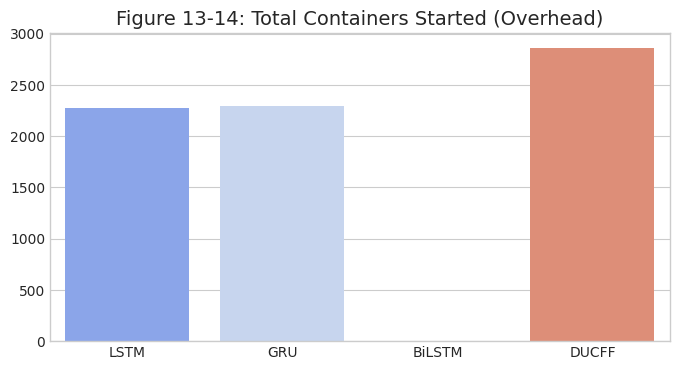

In [7]:
started_containers = {}
for name, supply in all_supplies.items():
    started_containers[name] = sum((supply[i] - supply[i-1]) for i in range(1, len(supply)) if supply[i] > supply[i-1])

plt.figure(figsize=(8, 4))
sns.barplot(x=list(started_containers.keys()), y=list(started_containers.values()), palette='coolwarm')
plt.title('Figure 13-14: Total Containers Started (Overhead)', fontsize=14)
plt.show()


### Figure 15, 16, 17: Qualitative Analysis of Demand vs Supply (GDS Algorithm)
Menunjukkan GDS beraksi menahan suplai replika kontainer secara bertahap saat beban merosot drastis (efek anak tangga biru).


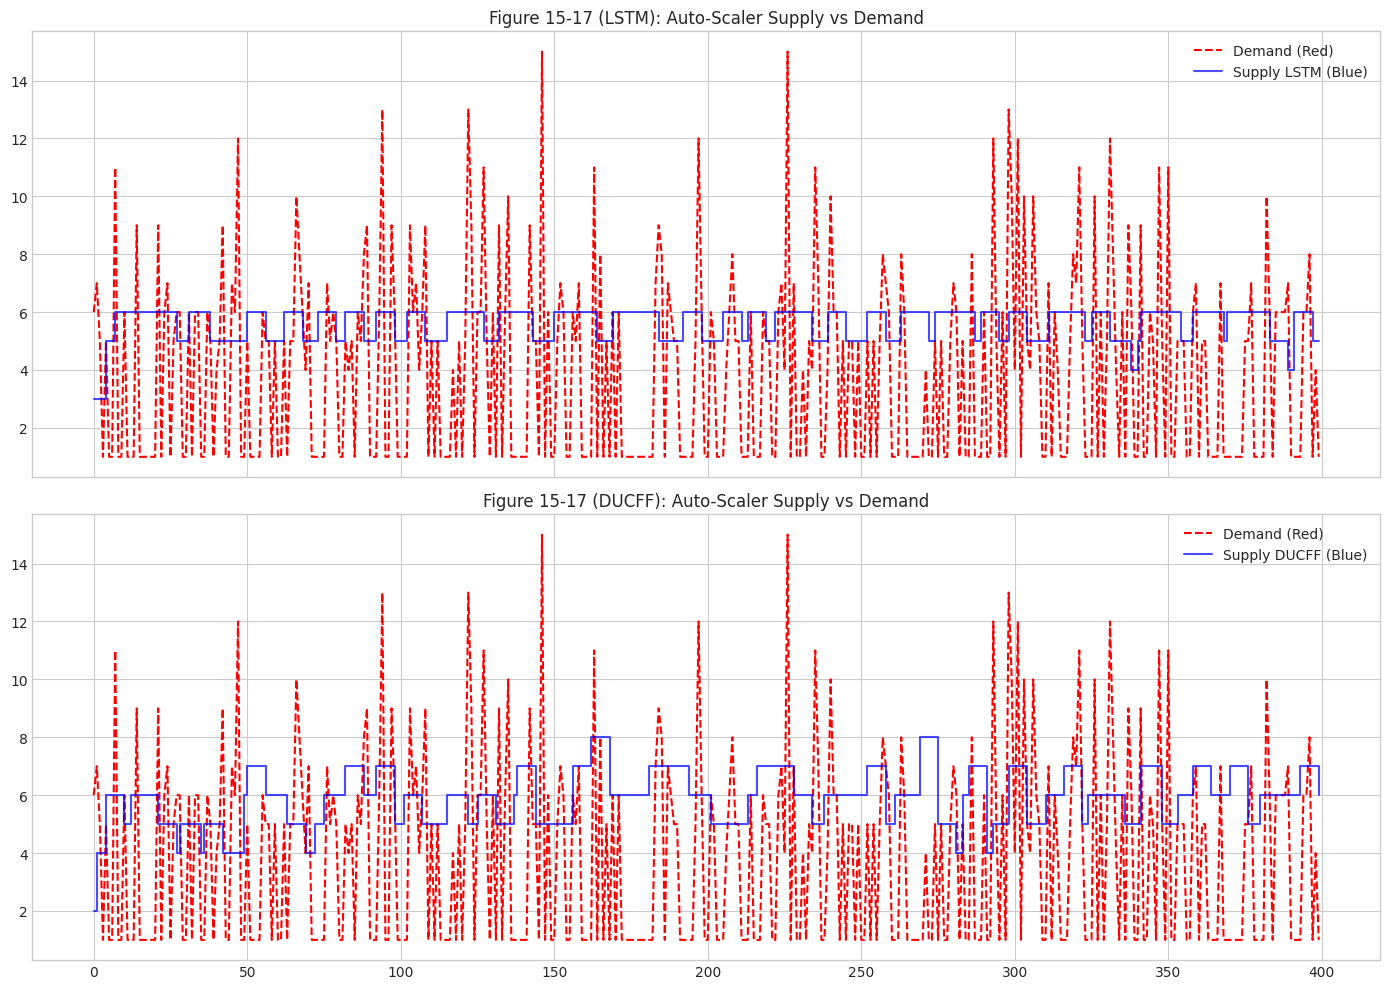

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
plot_len = 400

for i, m_name in enumerate(['LSTM', 'DUCFF']):
    axes[i].plot(demand_real[:plot_len], label='Demand (Red)', color='red', linestyle='--')
    axes[i].plot(all_supplies[m_name][:plot_len], label=f'Supply {m_name} (Blue)', color='blue', drawstyle='steps-post', alpha=0.7)
    axes[i].set_title(f'Figure 15-17 ({m_name}): Auto-Scaler Supply vs Demand', fontsize=12)
    axes[i].legend()

plt.tight_layout()
plt.show()
